In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib as mpl
from matplotlib.lines import Line2D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm

from adjustText import adjust_text

### 1. Import necessary datasets 

In [16]:
#median_income = pd.read_excel("/Users/dolgayamaria/Thesis/Practical Part/Data/ssb_06944/06944_2023.xlsx")
edu_level = pd.read_excel("/Users/dolgayamaria/Thesis/Practical Part/Data/ssb_09429/09429_2024.xlsx", header=4, nrows=359,engine="openpyxl")
counties_masks_2024 = gpd.read_file('/Users/dolgayamaria/Thesis/Practical Part/Data/ssb_counties_masks/Fylker 2024.shp')
municipal_masks_2024 = gpd.read_file('/Users/dolgayamaria/Thesis/Practical Part/Data/ssb_municipalities_masks/Kommuner 2024.shp')
summary_df = pd.read_csv('summary_df.csv',dtype={"kommunenum": str})
ms_emissions_agg = pd.read_csv('ms_emissions_agg.csv',dtype={"kommunenum": str})
manufacturing_emissions_agg = pd.read_csv('manufacturing_emissions_agg.csv',dtype={"kommunenum": str})

material_stock_agg = pd.read_csv('material_stock_agg.csv',dtype={"kommunenum": str})
municipalities_coast = gpd.read_file('/Users/dolgayamaria/Thesis/Practical Part/Data/Geopackage/Kommuner.gpkg')
municipalities_coast = municipalities_coast.rename(columns={"nummer": "kommunenum"})
municipalities_coast = municipalities_coast.rename(columns={"navn": "kommunenav"})
municipalities_coast["kommunenum"] = municipalities_coast["kommunenum"].astype(str).str.zfill(4)

### 2. Import and work on population data

In [17]:
population_2024 = pd.read_excel(
    "/Users/dolgayamaria/Thesis/Practical Part/Data/01222_20250626-164638.xlsx",
    skiprows=3,
    header=0,
    nrows=360
)

# Rename the first column to 'raw'
population_2024 = population_2024.rename(columns={population_2024.columns[0]: 'raw'})

# Drop the unwanted “K-21-22…”, “K-23…” and “K-Rest…” rows
exclude = [
    'K-21-22 Svalbard and Jan Mayen',
    'K-23 Continental shelf',
    'K-Rest Divided municalities and unknown'
]
population_2024 = population_2024[~population_2024['raw'].isin(exclude)]

# Use regex to extract the 4-digit code and the municipality name in one go
# raw e.g. "K-3101 Halden"
population_2024[['kommunenum', 'kommunenav']] = population_2024['raw'] \
    .str.extract(r'K-(\d{4})\s+(.+)$')

# Drop the helper column
population_2024 = population_2024.drop(columns=['raw'])

# Rename the remaining data column to 'population'
population_2024 = population_2024.rename(columns={population_2024.columns[0]: 'population'})

# Reorder
population_2024 = population_2024[['kommunenum', 'kommunenav', 'population']]

### 3. Import and work on data on Gross Domestic Product

The data is only available at county level, so it is nevessary to convert it to municipal level by using the same values for each municipaliity within the county

In [18]:
gdp_df = pd.read_excel('/Users/dolgayamaria/Thesis/Practical Part/Data/Regional accounts, figures per inhabitant and per employed person. Regional value added is measured in basic value..xlsx', header=1)
gdp_df = gdp_df.rename(columns={
    'Unnamed: 0': 'fylkesnavn',
    'GDP per inhabitant': 'gdp_capita',
    'GDP per employed person': 'gdp_per_employed'
})

# Clean out parentheticals and trailing spaces to help with joins
gdp_df['fylkesnavn_clean'] = gdp_df['fylkesnavn'].str.extract(r'(^[^(\-]+)').iloc[:, 0].str.strip()

gdp_df = gdp_df.dropna(subset=['gdp_capita'])

counties_masks_2024['fylkesnavn_clean'] = counties_masks_2024['fylkesnavn'].str.extract(r'(^[^(\-]+)').iloc[:, 0].str.strip()

# Merge GDP into county GeoDataFrame
counties_gdp = counties_masks_2024.merge(
    gdp_df[['fylkesnavn_clean', 'gdp_capita']],
    on='fylkesnavn_clean',
    how='left'
)

fill_map = {
    'Østfold': 492,
    'Akershus': 492,
    'Buskerud': 492,
    'Vestfold': 488,
    'Telemark': 488,
    'Troms': 546,
    'Finnmark': 546
}

counties_gdp['gdp_capita'] = counties_gdp.apply(
    lambda row: fill_map.get(row['fylkesnavn_clean'], row['gdp_capita']),
    axis=1
)

municipal_masks_2024 = municipal_masks_2024.to_crs(counties_gdp.crs)

municipal_with_gdp = gpd.sjoin(
    municipal_masks_2024,
    counties_gdp[['geometry', 'gdp_capita']],
    how='left',
    predicate='within'
)

municipal_dpp = municipal_with_gdp[['kommunenum', 'gdp_capita']]
# Clean out parentheticals and trailing spaces to help with joins
gdp_df['fylkesnavn_clean'] = gdp_df['fylkesnavn'].str.extract(r'(^[^(\-]+)').iloc[:, 0].str.strip()
gdp_df = gdp_df.dropna(subset=['gdp_capita'])
counties_masks_2024['fylkesnavn_clean'] = counties_masks_2024['fylkesnavn'].str.extract(r'(^[^(\-]+)').iloc[:, 0].str.strip()

# Merge GDP into county GeoDataFrame
counties_gdp = counties_masks_2024.merge(
    gdp_df[['fylkesnavn_clean', 'gdp_capita']],
    on='fylkesnavn_clean',
    how='left'
)
fill_map = {
    'Østfold': 492,
    'Akershus': 492,
    'Buskerud': 492,
    'Vestfold': 488,
    'Telemark': 488,
    'Troms': 546,
    'Finnmark': 546
}

counties_gdp['gdp_capita'] = counties_gdp.apply(
    lambda row: fill_map.get(row['fylkesnavn_clean'], row['gdp_capita']),
    axis=1
)
municipal_masks_2024 = municipal_masks_2024.to_crs(counties_gdp.crs)

municipal_with_gdp = gpd.sjoin(
    municipal_masks_2024,
    counties_gdp[['geometry', 'gdp_capita']],
    how='left',
    predicate='within'
)

municipal_dpp = municipal_with_gdp[['kommunenum', 'gdp_capita']]

### 4. Find centriod within each municipality

In [19]:
municipal_masks_2024 = municipal_masks_2024.to_crs(epsg=4326)
municipal_masks_2024['centroid'] = municipal_masks_2024.geometry.centroid
municipal_masks_2024['latitude'] = municipal_masks_2024.centroid.y

/var/folders/kn/87q7q5h140ldb97ht3jdcpr00000gn/T/ipykernel_7413/4169572531.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  municipal_masks_2024['centroid'] = municipal_masks_2024.geometry.centroid
/var/folders/kn/87q7q5h140ldb97ht3jdcpr00000gn/T/ipykernel_7413/4169572531.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  municipal_masks_2024['latitude'] = municipal_masks_2024.centroid.y


### 5. Perform statistical analysis

EPSG:25833


/var/folders/kn/87q7q5h140ldb97ht3jdcpr00000gn/T/ipykernel_7413/1366036221.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  edu_shares['kommunenum'] = edu_shares['kommunenum'].astype(str)


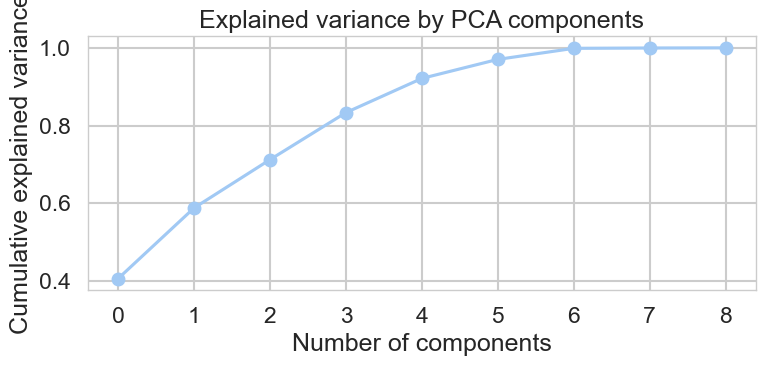

Component 1 loadings:
  basic_school_share: -0.323
  secondary_school_share: -0.238
  higher_education_share: 0.429
  pop_density: 0.373
  area_km2: -0.154
  material_stock_capita: -0.446
  emissions_capita: -0.460
  gdp_capita: 0.084
  latitude: -0.274

Component 2 loadings:
  basic_school_share: 0.327
  secondary_school_share: -0.647
  higher_education_share: 0.241
  pop_density: 0.252
  area_km2: 0.229
  material_stock_capita: 0.088
  emissions_capita: 0.050
  gdp_capita: -0.006
  latitude: 0.539

Component 3 loadings:
  basic_school_share: -0.455
  secondary_school_share: 0.187
  higher_education_share: 0.209
  pop_density: 0.103
  area_km2: 0.427
  material_stock_capita: 0.203
  emissions_capita: 0.199
  gdp_capita: 0.650
  latitude: 0.135



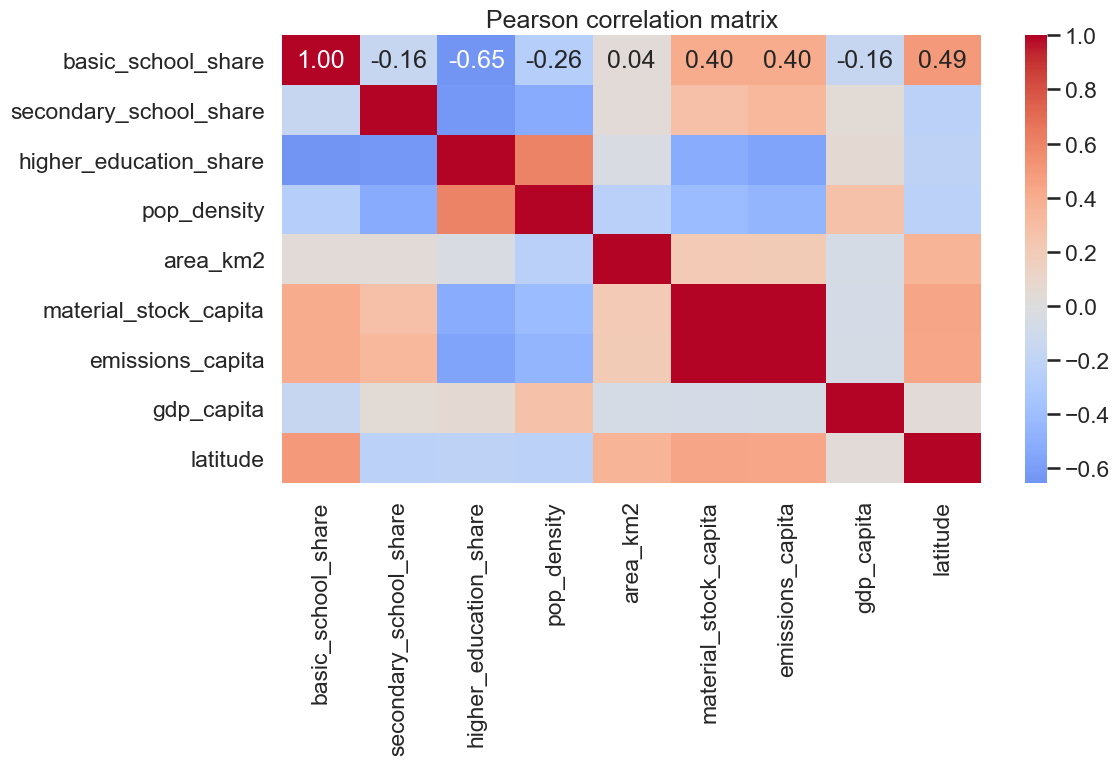

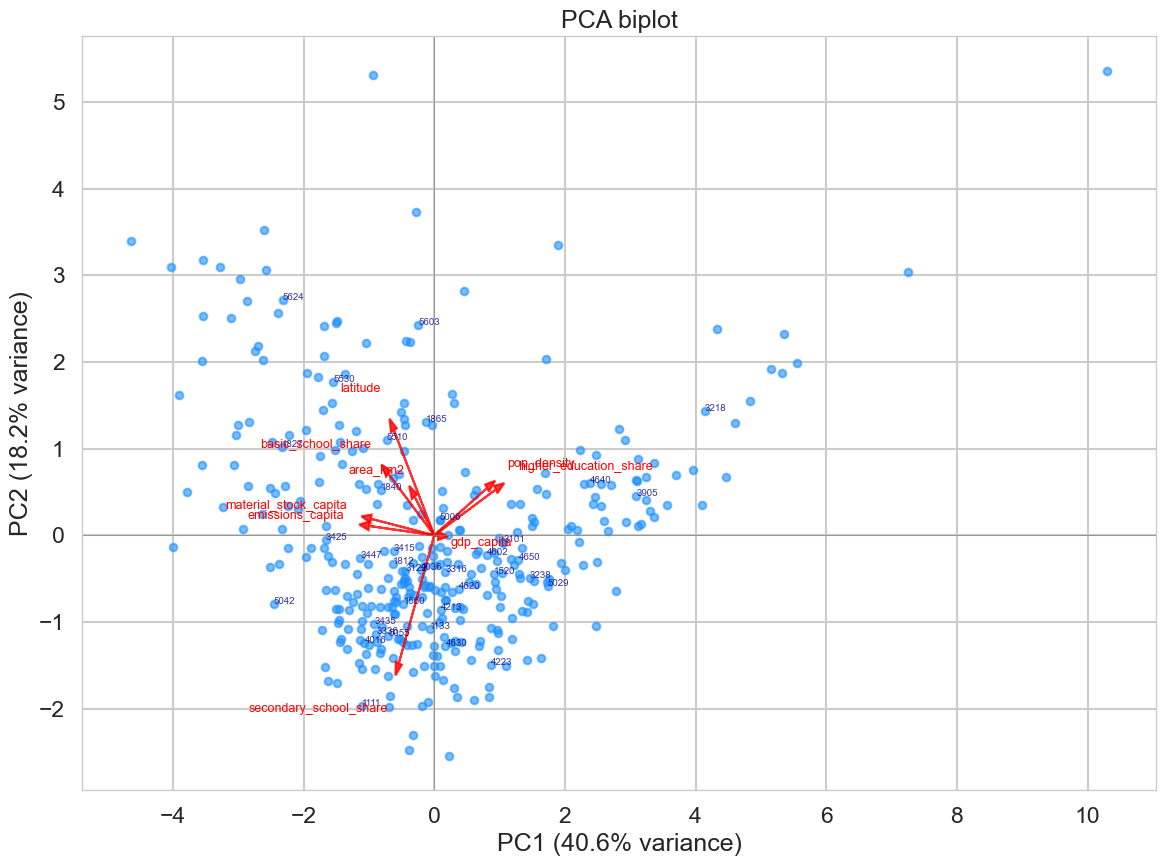

In [20]:
# -----------------------------------------------------------------------------
# 2. CLEAN EDUCATION DATA
# -----------------------------------------------------------------------------
edu_level = edu_level.drop(edu_level.columns[0], axis=1).reset_index(drop=True)
edu_level.rename(columns={edu_level.columns[0]: "kommunenum_raw"}, inplace=True)

# Extract kommunenum and kommunenavn, keep leading zero by keeping it a string
edu_level[['kommunenum', 'kommunavn']] = edu_level['kommunenum_raw'].str.extract(r'(\d{4})\s*(.*)', expand=True)

# Drop rows where kommunenum is missing
edu_level = edu_level.dropna(subset=['kommunenum'])


# -----------------------------------------------------------------------------
# 3. AGGREGATE EMISSIONS
# -----------------------------------------------------------------------------
emissions_sum = summary_df.groupby('kommunenum', as_index=False)['total_mean'].sum()
emissions_sum.rename(columns={'total_mean': 'emissions_total_mean'}, inplace=True)

# Merge with population
emissions_merged = emissions_sum.merge(
    population_2024[['kommunenum', 'population']],
    on='kommunenum',
    how='left'
)
emissions_merged['emissions_capita'] = emissions_merged['emissions_total_mean'] / emissions_merged['population']
emissions_merged = emissions_merged.drop(columns=['emissions_total_mean', 'population'])

# -----------------------------------------------------------------------------
# 4. POPULATION DENSITY FROM GEODATAFRAME
# -----------------------------------------------------------------------------
# Ensure kommunenum is the index or column for dissolving
municipalities_dissolved = municipalities_coast.dissolve(by='kommunenum', as_index=False)
pop_gdf = municipalities_dissolved.merge(population_2024, on='kommunenum', how='inner')
print(pop_gdf.crs)
pop_gdf['area_km2'] = pop_gdf.geometry.area / 1e6
pop_gdf['pop_density'] = pop_gdf['population'] / pop_gdf['area_km2']
pop_density = pop_gdf[['kommunenum', 'pop_density']].copy()
area = pop_gdf[['kommunenum', 'area_km2']].copy()

# -----------------------------------------------------------------------------
# 5. MATERIAL STOCK
# -----------------------------------------------------------------------------
ms_total = material_stock_agg[material_stock_agg['material'] == 'TOTAL'].copy()
material_stock_summary = ms_total.groupby('kommunenum', as_index=False)['material_stock_mean'].sum()
material_stock_summary.rename(columns={'material_stock_mean': 'material_stock_total_mean'}, inplace=True)

material_stock_summary['kommunenum'] = material_stock_summary['kommunenum'].astype(str)
population_2024['kommunenum'] = population_2024['kommunenum'].astype(str)

material_stock_merged = material_stock_summary.merge(
    population_2024[['kommunenum', 'population']],
    on='kommunenum',
    how='left'
)
material_stock_merged['material_stock_capita'] = material_stock_merged['material_stock_total_mean'] / material_stock_merged['population']
material_stock_merged = material_stock_merged.drop(columns=['material_stock_total_mean', 'population'])


# -----------------------------------------------------------------------------
# 7. EDUCATION SHARES
# -----------------------------------------------------------------------------
edu = edu_level.copy()
edu_cnt_cols = [
    'Total',
    'Basic school level',
    'Upper secondary education',
    'Tertiary vocational education',
    'Higher education, short',
    'Higher education, long',
    'Unknown or no completed education'
]

# Ensure numeric types
edu[edu_cnt_cols] = edu[edu_cnt_cols].apply(pd.to_numeric, errors='coerce')

# Calculate new share columns
edu['basic_school_share'] = edu['Basic school level'] / edu['Total']
edu['secondary_school_share'] = edu['Upper secondary education'] / edu['Total']
edu['higher_education_share'] = (
    edu['Higher education, short'] + edu['Higher education, long']
) / edu['Total']

# Keep only relevant columns
edu_shares = edu[['kommunenum', 
                  'basic_school_share', 
                  'secondary_school_share', 
                  'higher_education_share']]

# -----------------------------------------------------------------------------
# 8. FINAL MERGE
# -----------------------------------------------------------------------------

edu_shares['kommunenum'] = edu_shares['kommunenum'].astype(str)
pop_density['kommunenum'] = pop_density['kommunenum'].astype(str)
area['kommunenum'] = area['kommunenum'].astype(str)
material_stock_merged['kommunenum'] = material_stock_merged['kommunenum'].astype(str)
emissions_merged['kommunenum'] = emissions_merged['kommunenum'].astype(str)
municipal_masks_2024['kommunenum'] = municipal_masks_2024['kommunenum'].astype(str)

df = (
      edu_shares.merge(pop_density, on='kommunenum')
      .merge(area, on='kommunenum')
      .merge(material_stock_merged, on='kommunenum')
      .merge(emissions_merged, on='kommunenum')
      .merge(municipal_dpp, on='kommunenum')
)

df = df.merge(
    municipal_masks_2024[['kommunenum', 'latitude']],
    on='kommunenum',
    how='left'
)

df = df.drop_duplicates()

# STYLING
# ----------------------------------------------------------------------------
sns.set(context="talk", style="whitegrid", palette="pastel")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.edgecolor"] = "#CCCCCC"
plt.rcParams["axes.linewidth"] = 1.0

# ----------------------------------------------------------------------------

# ----------------------------------------------------------------------------
# 9. PCA
# ----------------------------------------------------------------------------
kommuner = df['kommunenum']
X = df.drop(columns=['kommunenum'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Scree plot
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Explained variance by PCA components')
plt.grid(True)
plt.tight_layout()
#plt.savefig("pca_scree_plot.png", dpi=300)
plt.show()

# Loadings
loadings = pca.components_[:3]
for i, comp in enumerate(loadings, 1):
    print(f"Component {i} loadings:")
    for feature, loading in zip(X.columns, comp):
        print(f"  {feature}: {loading:.3f}")
    print()

# ----------------------------------------------------------------------------
# 11. CORRELATION MATRIX
# ----------------------------------------------------------------------------
corr = df.drop(columns=['kommunenum']).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Pearson correlation matrix")
plt.tight_layout()
#plt.savefig("correlation_matrix.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------------
# 12. PCA BIPLOT
# ----------------------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 9))

# Scatter plot of municipalities
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=30, color='dodgerblue')

# Label every 10th municipality
for i in range(len(kommuner)):
    if i % 10 == 0:
        ax.text(X_pca[i, 0], X_pca[i, 1], kommuner[i],
                fontsize=7, alpha=0.8, color='navy')

# Arrows for loadings
loadings = pca.components_.T
arrow_size = 2.5

for i, feature in enumerate(X.columns):
    x_arrow = arrow_size * loadings[i, 0]
    y_arrow = arrow_size * loadings[i, 1]

    # Draw arrow
    ax.arrow(0, 0, x_arrow, y_arrow, color='red', alpha=0.8,
             head_width=0.1, length_includes_head=True)

    # Offset label based on direction
    ha = 'left' if x_arrow >= 0 else 'right'
    va = 'bottom' if y_arrow >= 0 else 'top'

    ax.text(x_arrow * 1.2, y_arrow * 1.2, feature, color='red',
            fontsize=9, ha=ha, va=va)

# Labels, grid, and formatting
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_title('PCA biplot')
ax.grid(True)
plt.tight_layout()
#plt.savefig("pca_biplot.png", dpi=300)
plt.show()
